# Hyperparameter Optimisation with Optuna

In [1]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize
import warnings

# Suppress Optuna's verbose logging for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)

/Users/paul-arthurmeslin/Documents/sqm_optuna/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Minimising a function

$$f(x, y) = (x - 1)^2 + (y + 2)^2$$

$x = 1$ and $y=-2$

In [2]:
def toy_objective(trial):
    x = trial.suggest_float("x", -5.0, 5.0)
    y = trial.suggest_float("y", -5.0, 5.0)
    return (x - 1) ** 2 + (y + 2) ** 2


# Create and run the study
toy_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
toy_study.optimize(toy_objective, n_trials=200)

print(f"Best value:  {toy_study.best_value:.6f}")
print(f"Best params: x = {toy_study.best_params['x']:.4f}, y = {toy_study.best_params['y']:.4f}")
print(f"True optimum: x = 1.0000, y = -2.0000")

Best value:  0.007194
Best params: x = 1.0367, y = -2.0765
True optimum: x = 1.0000, y = -2.0000


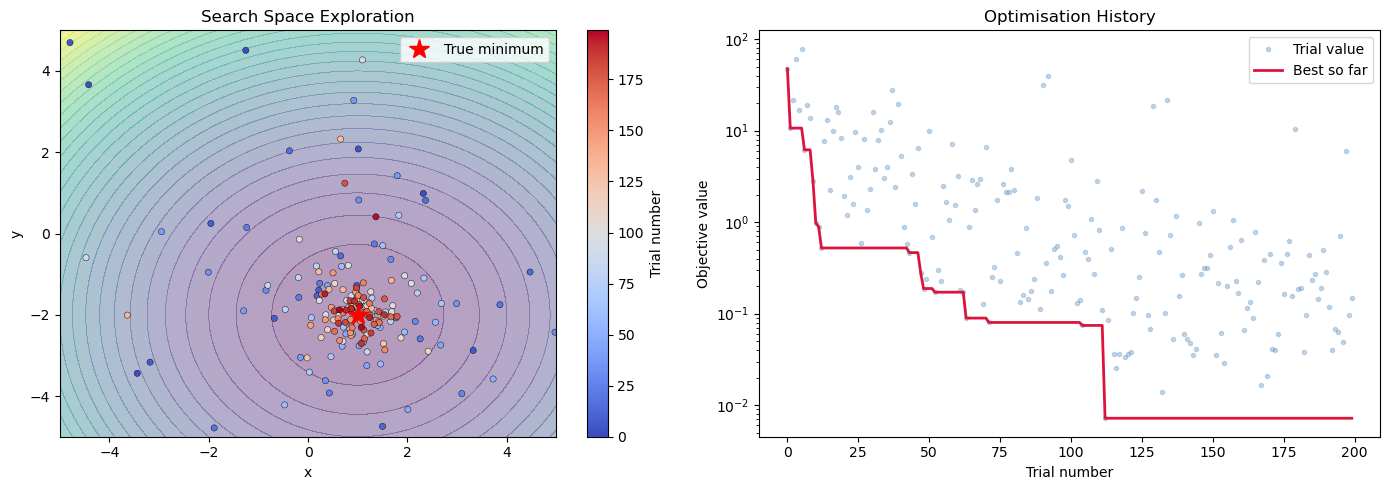

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
trials = toy_study.trials
xs = [t.params["x"] for t in trials]
ys = [t.params["y"] for t in trials]
vals = [t.value for t in trials]
trial_nums = list(range(len(trials)))

# True objective contour
xg = np.linspace(-5, 5, 100)
yg = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(xg, yg)
Z = (X - 1) ** 2 + (Y + 2) ** 2
ax.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.4)
scatter = ax.scatter(xs, ys, c=trial_nums, cmap="coolwarm", s=20, edgecolors="k", linewidth=0.3)
ax.plot(1, -2, "r*", markersize=15, label="True minimum")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Search Space Exploration")
ax.legend()
plt.colorbar(scatter, ax=ax, label="Trial number")

# History
ax = axes[1]
best_so_far = np.minimum.accumulate(vals)
ax.plot(trial_nums, vals, ".", alpha=0.3, color="steelblue", label="Trial value")
ax.plot(trial_nums, best_so_far, "-", color="crimson", linewidth=2, label="Best so far")
ax.set_xlabel("Trial number")
ax.set_ylabel("Objective value")
ax.set_title("Optimisation History")
ax.set_yscale("log")
ax.legend()

plt.tight_layout()
plt.show()

---
## Grid vs. Random vs. Bayesian (TPE)

We compare three search strategies on the same 2D objective.

The Rastrigin function is a non-convex function used as a performance test problem for optimization algorithms.

<img src="https://upload.wikimedia.org/wikipedia/commons/8/8b/Rastrigin_function.png" width="500">

In [4]:
def rastrigin_2d(x, y):
    """Rastrigin function — many local minima, global min at (0, 0)."""
    return 20 + (x**2 - 10 * np.cos(2 * np.pi * x)) + (y**2 - 10 * np.cos(2 * np.pi * y))


def objective_rastrigin(trial):
    x = trial.suggest_float("x", -5.12, 5.12)
    y = trial.suggest_float("y", -5.12, 5.12)
    return rastrigin_2d(x, y)


N_TRIALS = 100

# --- Grid search ---
grid_space = {
    "x": np.linspace(-5.12, 5.12, 10).tolist(),
    "y": np.linspace(-5.12, 5.12, 10).tolist(),
}
grid_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.GridSampler(grid_space))
grid_study.optimize(objective_rastrigin, n_trials=N_TRIALS)

# --- Random search ---
random_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.RandomSampler(seed=SEED))
random_study.optimize(objective_rastrigin, n_trials=N_TRIALS)

# --- TPE (Bayesian) ---
tpe_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
tpe_study.optimize(objective_rastrigin, n_trials=N_TRIALS)

print(f"{'Strategy':<12} {'Best Value':>12} {'Best x':>10} {'Best y':>10}")
print("-" * 46)
for name, s in [("Grid", grid_study), ("Random", random_study), ("TPE", tpe_study)]:
    print(f"{name:<12} {s.best_value:>12.4f} {s.best_params['x']:>10.4f} {s.best_params['y']:>10.4f}")

Strategy       Best Value     Best x     Best y
----------------------------------------------
Grid              24.9979    -2.8444    -2.8444
Random             4.2019     1.1219     0.0274
TPE                0.0020     0.0019    -0.0026


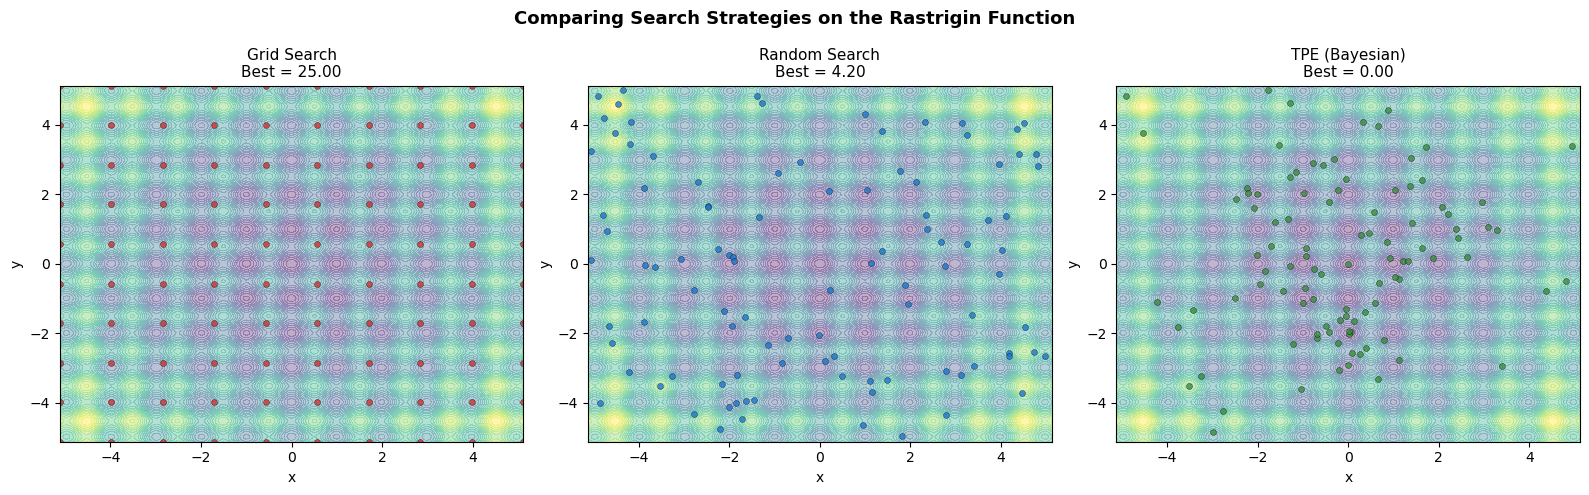

In [5]:
# Side-by-side visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Background contour
xg = np.linspace(-5.12, 5.12, 200)
yg = np.linspace(-5.12, 5.12, 200)
X, Y = np.meshgrid(xg, yg)
Z = rastrigin_2d(X, Y)

studies = [("Grid Search", grid_study), ("Random Search", random_study), ("TPE (Bayesian)", tpe_study)]
colors = ["#D32F2F", "#1976D2", "#388E3C"]

for ax, (name, study), color in zip(axes, studies, colors):
    ax.contourf(X, Y, Z, levels=30, cmap="viridis", alpha=0.35)
    xs = [t.params["x"] for t in study.trials]
    ys = [t.params["y"] for t in study.trials]
    ax.scatter(xs, ys, c=color, s=18, edgecolors="k", linewidth=0.3, alpha=0.8)
    # ax.plot(0, 0, "w*", markersize=12)
    ax.set_title(f"{name}\nBest = {study.best_value:.2f}", fontsize=11)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Comparing Search Strategies on the Rastrigin Function", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Tuning a Real ML Model

We optimise a **Random Forest** classifier on the Breast Cancer Wisconsin dataset.

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Load data
X_data, y_data = load_breast_cancer(return_X_y=True)
print(f"Dataset: {X_data.shape[0]} samples, {X_data.shape[1]} features")
print(f"Classes: {np.unique(y_data)} (0=malignant, 1=benign)")
print(f"Class balance: {y_data.mean():.1%} benign")

X_data, y_data

Dataset: 569 samples, 30 features
Classes: [0 1] (0=malignant, 1=benign)
Class balance: 62.7% benign


(array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [7]:
def rf_objective(trial):
    """Optimise Random Forest hyperparameters."""
    # Define the search space INSIDE the objective (define-by-run!)
    n_estimators = trial.suggest_int("n_estimators", 50, 500, step=50)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=SEED,
    )

    # 5-fold cross-validation
    scores = cross_val_score(clf, X_data, y_data, cv=5, scoring="accuracy")
    return scores.mean()


# Run optimisation
rf_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name="random_forest_hpo",
)
rf_study.optimize(rf_objective, n_trials=80)

print(f"\nBest accuracy: {rf_study.best_value:.4f}")
print(f"Best hyperparameters:")
for k, v in rf_study.best_params.items():
    print(f"  {k}: {v}")


Best accuracy: 0.9631
Best hyperparameters:
  n_estimators: 350
  max_depth: 14
  min_samples_split: 3
  min_samples_leaf: 2
  max_features: sqrt


---
## Visualisation

Optuna provides rich built-in visualisation.

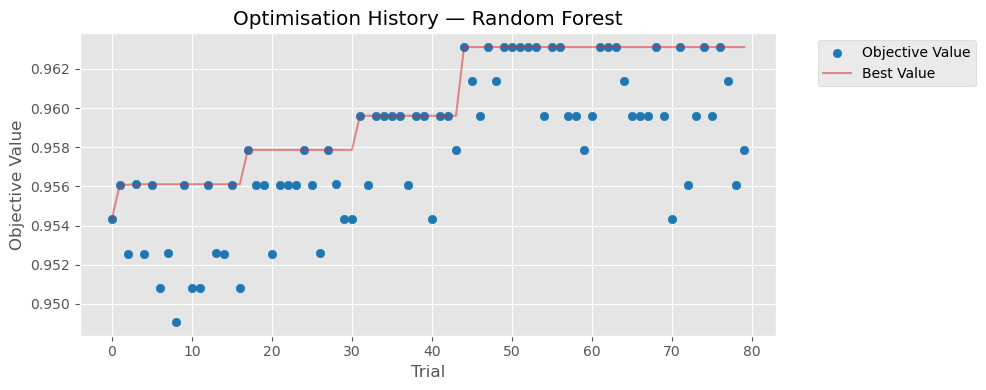

In [8]:
# We use matplotlib-based visualisation (no Plotly dependency needed)
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_parallel_coordinate,
    plot_contour,
)

# 1. Optimisation History
plot_optimization_history(rf_study)
plt.gcf().set_size_inches(10, 4)
plt.title("Optimisation History — Random Forest")
plt.tight_layout()
plt.show()

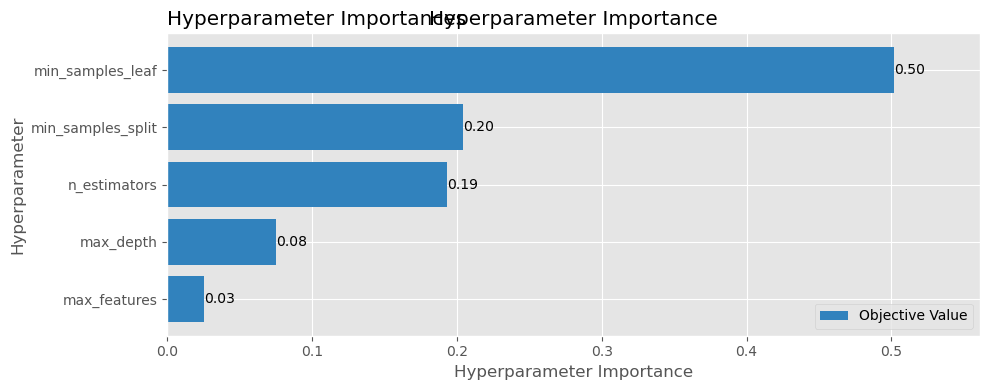

In [9]:
# 2. Parameter Importance
plot_param_importances(rf_study)
plt.gcf().set_size_inches(10, 4)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

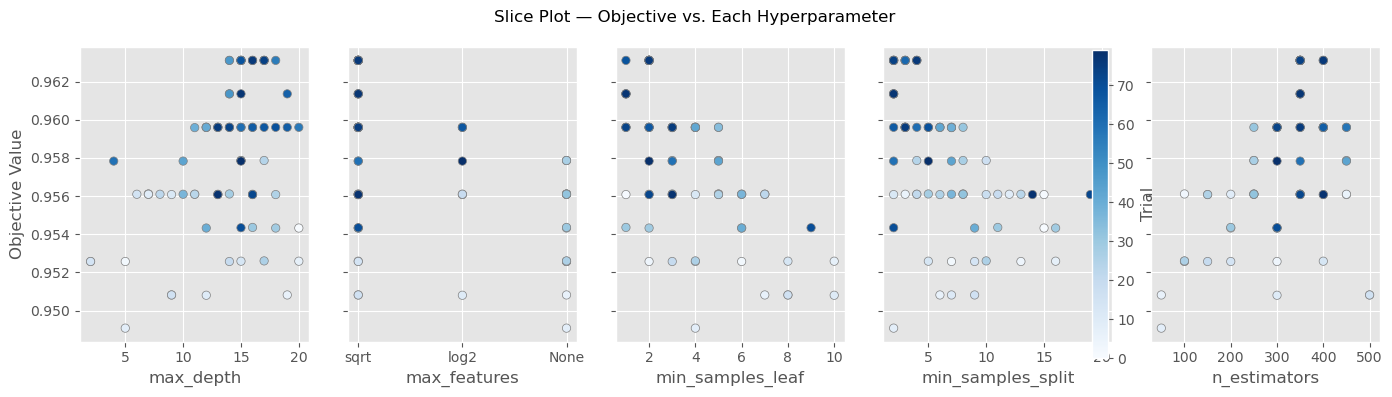

In [10]:
# 3. Slice Plot — objective as a function of each parameter
plot_slice(rf_study)
plt.gcf().set_size_inches(14, 4)
plt.suptitle("Slice Plot — Objective vs. Each Hyperparameter", fontsize=12)
plt.tight_layout()
plt.show()

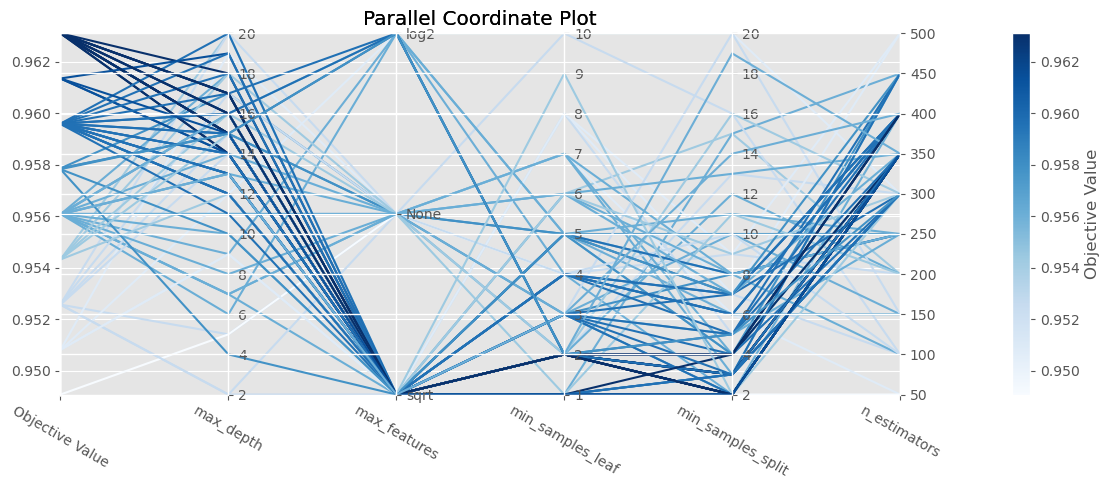

In [11]:
# 4. Parallel Coordinate Plot
plot_parallel_coordinate(rf_study)
plt.gcf().set_size_inches(12, 5)
plt.title("Parallel Coordinate Plot")
plt.tight_layout()
plt.show()

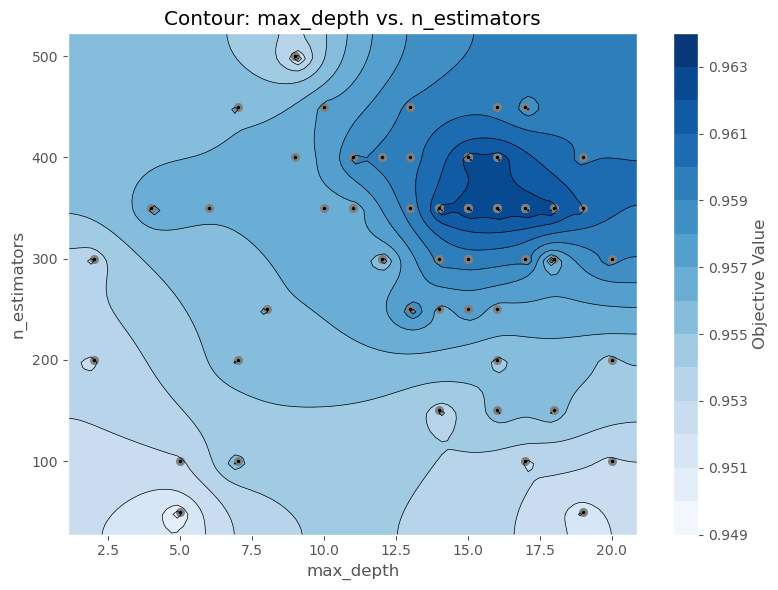

In [12]:
# 5. Contour Plot — interaction between two parameters
plot_contour(rf_study, params=["max_depth", "n_estimators"])
plt.gcf().set_size_inches(8, 6)
plt.title("Contour: max_depth vs. n_estimators")
plt.tight_layout()
plt.show()

---
## Pruning

Pruning allows Optuna to **terminate unpromising trials early**.
This is especially valuable for expensive training jobs (deep learning, large datasets).

In [13]:
from sklearn.datasets import load_digits
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold

X_digits, y_digits = load_digits(return_X_y=True)


def pruning_objective(trial):
    """Objective with intermediate reporting for pruning."""
    alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    clf = SGDClassifier(
        loss="log_loss",
        penalty="elasticnet",
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=1,  # We control iterations manually
        warm_start=True,
        random_state=SEED,
    )

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    train_idx, val_idx = next(iter(skf.split(X_digits, y_digits)))

    for step in range(50):
        clf.fit(X_digits[train_idx], y_digits[train_idx])
        accuracy = clf.score(X_digits[val_idx], y_digits[val_idx])

        # Report intermediate value
        trial.report(accuracy, step)

        # Check if trial should be pruned
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return accuracy


# Run WITH pruning
pruned_study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
pruned_study.optimize(pruning_objective, n_trials=50)

# Count pruned vs. completed
n_pruned = len([t for t in pruned_study.trials if t.state == optuna.trial.TrialState.PRUNED])
n_complete = len([t for t in pruned_study.trials if t.state == optuna.trial.TrialState.COMPLETE])

print(f"Completed trials: {n_complete}")
print(f"Pruned trials:    {n_pruned}")
print(f"Pruning rate:     {n_pruned / 50:.0%}")
print(f"Best accuracy:    {pruned_study.best_value:.4f}")
print(f"\nPruning saved ~{n_pruned * 50} unnecessary training steps!")

Completed trials: 36
Pruned trials:    14
Pruning rate:     28%
Best accuracy:    0.9566

Pruning saved ~700 unnecessary training steps!


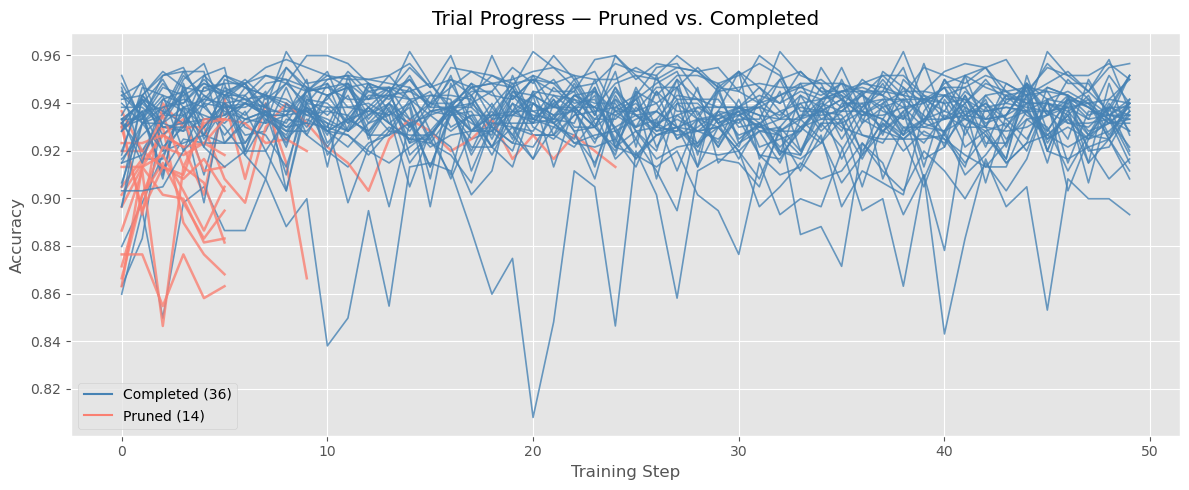

Red lines = trials stopped early (clearly underperforming).
Blue lines = trials that ran to completion.


In [14]:
# Visualise pruning: intermediate values for each trial
fig, ax = plt.subplots(figsize=(12, 5))

for trial in pruned_study.trials:
    steps = sorted(trial.intermediate_values.keys())
    values = [trial.intermediate_values[s] for s in steps]
    if trial.state == optuna.trial.TrialState.PRUNED:
        ax.plot(steps, values, color="salmon", alpha=0.8, linewidth=1.8)
    else:
        ax.plot(steps, values, color="steelblue", alpha=0.8, linewidth=1.2)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="steelblue", label=f"Completed ({n_complete})"),
    Line2D([0], [0], color="salmon", label=f"Pruned ({n_pruned})"),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Training Step")
ax.set_ylabel("Accuracy")
ax.set_title("Trial Progress — Pruned vs. Completed")
plt.tight_layout()
plt.show()

print("Red lines = trials stopped early (clearly underperforming).")
print("Blue lines = trials that ran to completion.")

---
## Multi-Objective Optimisation

In practice, you often care about **multiple objectives** simultaneously:
accuracy AND inference time, precision AND recall.

Optuna handles this natively with **Pareto optimisation**.

In [15]:
import time


def multi_objective(trial):
    """Optimise accuracy AND training speed simultaneously."""
    n_estimators = trial.suggest_int("n_estimators", 10, 500)
    max_depth = trial.suggest_int("max_depth", 2, 20)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=SEED,
    )

    # Objective 1: accuracy (maximise)
    scores = cross_val_score(clf, X_data, y_data, cv=3, scoring="accuracy")
    accuracy = scores.mean()

    # Objective 2: training time (minimise)
    t0 = time.perf_counter()
    clf.fit(X_data, y_data)
    train_time = time.perf_counter() - t0

    return accuracy, train_time


mo_study = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
mo_study.optimize(multi_objective, n_trials=60)

print(f"Number of Pareto-optimal solutions: {len(mo_study.best_trials)}")
print(f"\nPareto front (accuracy, training time):")
for t in sorted(mo_study.best_trials, key=lambda t: t.values[0], reverse=True)[:5]:
    print(f"  Acc={t.values[0]:.4f}, Time={t.values[1]:.4f}s | n_est={t.params['n_estimators']}, depth={t.params['max_depth']}")

Number of Pareto-optimal solutions: 4

Pareto front (accuracy, training time):
  Acc=0.9631, Time=0.0361s | n_est=52, depth=13
  Acc=0.9613, Time=0.0215s | n_est=31, depth=13
  Acc=0.9596, Time=0.0089s | n_est=13, depth=20
  Acc=0.9508, Time=0.0071s | n_est=10, depth=19


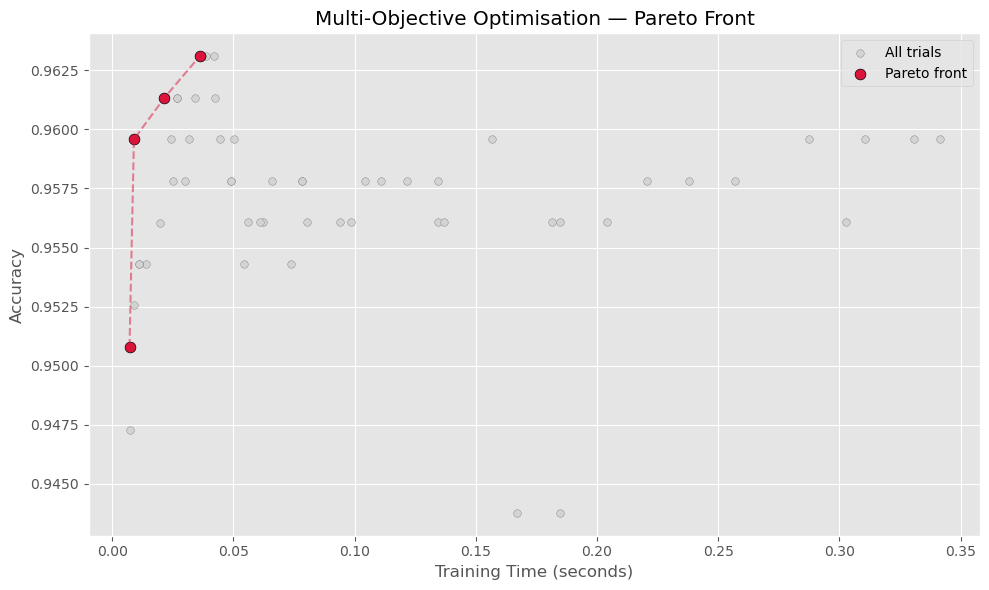

The Pareto front shows the BEST possible trade-offs.
Moving along the front: you can only improve one objective by sacrificing the other.


In [16]:
# Pareto front visualisation
fig, ax = plt.subplots(figsize=(10, 6))

# All trials
all_acc = [t.values[0] for t in mo_study.trials if t.state == optuna.trial.TrialState.COMPLETE]
all_time = [t.values[1] for t in mo_study.trials if t.state == optuna.trial.TrialState.COMPLETE]
ax.scatter(all_time, all_acc, c="lightgray", s=30, edgecolors="gray", linewidth=0.3, label="All trials", zorder=1)

# Pareto front
pareto_acc = [t.values[0] for t in mo_study.best_trials]
pareto_time = [t.values[1] for t in mo_study.best_trials]
ax.scatter(pareto_time, pareto_acc, c="crimson", s=60, edgecolors="k", linewidth=0.5, label="Pareto front", zorder=2)

# Connect Pareto front
sorted_pareto = sorted(zip(pareto_time, pareto_acc))
ax.plot([p[0] for p in sorted_pareto], [p[1] for p in sorted_pareto], "--", color="crimson", alpha=0.5, zorder=2)

ax.set_xlabel("Training Time (seconds)")
ax.set_ylabel("Accuracy")
ax.set_title("Multi-Objective Optimisation — Pareto Front")
ax.legend()
plt.tight_layout()
plt.show()

print("The Pareto front shows the BEST possible trade-offs.")
print("Moving along the front: you can only improve one objective by sacrificing the other.")

---
## Storage & reproducibility

Persisting studies to a database enables:
- Resuming interrupted optimisation
- Sharing results with teammates  
- Full audit trail of every experiment

In [17]:
import os

DB_PATH = "sqlite:///optuna_demo.db"

# Clean up any previous run
if os.path.exists("optuna_demo.db"):
    os.remove("optuna_demo.db")

# --- Session 1: Start optimisation ---
study_v1 = optuna.create_study(
    study_name="persistent_demo",
    storage=DB_PATH,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_v1.optimize(toy_objective, n_trials=30)
print(f"Session 1: {len(study_v1.trials)} trials, best = {study_v1.best_value:.6f}")

# --- Session 2: Resume (as if restarting your script) ---
study_v2 = optuna.load_study(
    study_name="persistent_demo",
    storage=DB_PATH,
)
study_v2.optimize(toy_objective, n_trials=30)
print(f"Session 2: {len(study_v2.trials)} trials total, best = {study_v2.best_value:.6f}")

# --- Inspect the study ---
print(f"\nAll trials are preserved in the database.")
print(f"Best params: {study_v2.best_params}")

Session 1: 30 trials, best = 0.522384
Session 2: 60 trials total, best = 0.008331

All trials are preserved in the database.
Best params: {'x': 1.0064089528502353, 'y': -1.9089519410637403}


In [18]:
# Export results to a DataFrame for further analysis
import pandas as pd

df = study_v2.trials_dataframe()
print(f"Trials DataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTop 5 trials:")
df.sort_values("value").head()

Trials DataFrame shape: (60, 8)

Columns: ['number', 'value', 'datetime_start', 'datetime_complete', 'duration', 'params_x', 'params_y', 'state']

Top 5 trials:


,number,value,datetime_start,datetime_complete,duration,params_x,params_y,state
36,36,0.008331,2026-03-20 11:20:46.684791,2026-03-20 11:20:46.689594,0 days 00:00:00.004803,1.006409,-1.908952,COMPLETE
42,42,0.129562,2026-03-20 11:20:46.725787,2026-03-20 11:20:46.730547,0 days 00:00:00.004760,0.950419,-1.643484,COMPLETE
59,59,0.401146,2026-03-20 11:20:46.839783,2026-03-20 11:20:46.844621,0 days 00:00:00.004838,0.404367,-1.784668,COMPLETE
52,52,0.424137,2026-03-20 11:20:46.793178,2026-03-20 11:20:46.798097,0 days 00:00:00.004919,0.572097,-1.509046,COMPLETE
53,53,0.507901,2026-03-20 11:20:46.799876,2026-03-20 11:20:46.804745,0 days 00:00:00.004869,0.570124,-1.431575,COMPLETE


---

### Resources

- [Optuna Documentation](https://optuna.readthedocs.io/)
- [Optuna GitHub](https://github.com/optuna/optuna)
- Bergstra & Bengio (2012). *Random Search for Hyper-Parameter Optimization.* JMLR.
- Akiba et al. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework.* KDD.